# 时间旅行
当使用基于模型的决策的非确定性系统（例如，由 LLM 驱动的代理）时，详细检查其决策过程会很有用：

- 🤔理解推理：分析导致成功结果的步骤。
- 🐞调试错误：确定错误发生的位置和原因。
- 🔍探索替代方案：测试不同的路径以发现更好的解决方案。

LangGraph 提供了时间旅行功能来支持这些用例。具体来说，您可以从之前的检查点恢复执行——可以重放相同的状态，也可以修改它以探索替代方案。在所有情况下，恢复过去的执行都会在历史记录中产生一个新的分叉。

# 使用时间旅行

要在 LangGraph 中使用时间旅行：

- 使用`invoke`或`stream`方法运行具有初始输入的图表。
- 识别现有线程中的检查点：使用该`get_state_history()`方法检索特定线程的执行历史记录`thread_id`并找到所需的检查点`checkpoint_id`。或者，在您希望暂停执行的节点之前设置中断。然后，您可以找到截至该中断为止记录的最新检查点。
- 更新图形状态（可选）：使用该`update_state`方法在检查点修改图形的状态并从替代状态恢复执行。
- 从检查点恢复执行：使用`invoke`或`stream`方法，输入为None，配置包含适当的`thread_id`和`checkpoint_id`。


## 在工作流程中¶
此示例构建了一个简单的 LangGraph 工作流，用于生成笑话主题并使用 LLM 编写笑话。它演示了如何运行该图、检索过去的执行检查点、选择性地修改状态，以及从选定的检查点恢复执行以探索其他结果。

### 设置¶
首先我们需要安装所需的软件包

```shell
%%capture --no-stderr
%pip install --quiet -U langgraph langchain_anthropic
```

接下来，我们需要为 Anthropic（我们将使用的 LLM）设置 API 密钥

In [ ]:
import getpass
import os


def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")


_set_env("ANTHROPIC_API_KEY")

注册 LangSmith，快速发现问题并提升 LangGraph 项目的性能。LangSmith 允许您使用跟踪数据来调试、测试和监控使用 LangGraph 构建的 LLM 应用——点击此处了解更多关于如何开始使用的信息。

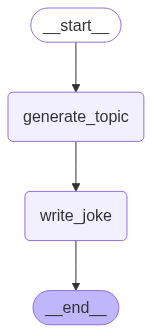

In [2]:
import uuid

from typing_extensions import TypedDict, NotRequired
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import InMemorySaver


class State(TypedDict):
    topic: NotRequired[str]
    joke: NotRequired[str]


llm = init_chat_model(
    "anthropic:claude-3-7-sonnet-latest",
    temperature=0,
)


def generate_topic(state: State):
    """LLM call to generate a topic for the joke"""
    msg = llm.invoke("Give me a funny topic for a joke")
    return {"topic": msg.content}


def write_joke(state: State):
    """LLM call to write a joke based on the topic"""
    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content}


# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_topic", generate_topic)
workflow.add_node("write_joke", write_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_topic")
workflow.add_edge("generate_topic", "write_joke")
workflow.add_edge("write_joke", END)

# Compile
checkpointer = InMemorySaver()
graph = workflow.compile(checkpointer=checkpointer)
graph

1. 运行图表¶

In [3]:
config = {
    "configurable": {
        "thread_id": uuid.uuid4(),
    }
}
state = graph.invoke({}, config)

print(state["topic"])
print()
print(state["joke"])

TypeError: "Could not resolve authentication method. Expected either api_key or auth_token to be set. Or for one of the `X-Api-Key` or `Authorization` headers to be explicitly omitted"

2. 确定检查点

In [ ]:
# The states are returned in reverse chronological order.
states = list(graph.get_state_history(config))

for state in states:
    print(state.next)
    print(state.config["configurable"]["checkpoint_id"])
    print()

# This is the state before last (states are listed in chronological order)
selected_state = states[1]
print(selected_state.next)
print(selected_state.values)

3.更新状态（可选）¶

update_state将创建一个新的检查点。新检查点将与同一线程相关联，但有一个新的检查点 ID。

In [ ]:
new_config = graph.update_state(selected_state.config, values={"topic": "chickens"})
print(new_config)

4. 从检查点恢复执行¶

In [ ]:
graph.invoke(None, new_config)

# 使用服务器 API 进行时间旅行

LangGraph 提供了时间旅行功能，可以从之前的检查点恢复执行，既可以重放相同的状态，也可以修改状态以探索替代方案。在所有情况下，恢复过去的执行都会在历史记录中产生新的分叉。

要使用 LangGraph Server API（通过 LangGraph SDK）进行时间旅行：

- 使用LangGraph SDK或client.runs.waitAPIclient.runs.stream以初始输入运行图表。
- 识别现有线程中的检查点：使用client.threads.get_history方法检索特定线程的执行历史记录thread_id并找到所需的检查点。或者，在要暂停执行的节点之前checkpoint_id设置断点。然后，您可以找到截至该断点的最新检查点记录。
- （可选）修改图形状态：使用该client.threads.update_state方法在检查点修改图形的状态并从替代状态恢复执行。
- 从检查点恢复执行：使用client.runs.wait或client.runs.streamAPI，并输入None和适当的thread_id和checkpoint_id。

## 在工作流中使用时间旅行


In [ ]:
from typing_extensions import TypedDict, NotRequired
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import InMemorySaver

class State(TypedDict):
    topic: NotRequired[str]
    joke: NotRequired[str]

llm = init_chat_model(
    "anthropic:claude-3-7-sonnet-latest",
    temperature=0,
)

def generate_topic(state: State):
    """LLM call to generate a topic for the joke"""
    msg = llm.invoke("Give me a funny topic for a joke")
    return {"topic": msg.content}

def write_joke(state: State):
    """LLM call to write a joke based on the topic"""
    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content}

# Build workflow
builder = StateGraph(State)

# Add nodes
builder.add_node("generate_topic", generate_topic)
builder.add_node("write_joke", write_joke)

# Add edges to connect nodes
builder.add_edge(START, "generate_topic")
builder.add_edge("generate_topic", "write_joke")

# Compile
graph = builder.compile()

1. 运行图表

In [ ]:
from langgraph_sdk import get_client
client = get_client(url=<DEPLOYMENT_URL>)

# Using the graph deployed with the name "agent"
assistant_id = "agent"

# create a thread
thread = await client.threads.create()
thread_id = thread["thread_id"]

# Run the graph
result = await client.runs.wait(
    thread_id,
    assistant_id,
    input={}
)

2. 确定检查点¶

In [ ]:
new_config = await client.threads.update_state(
    thread_id,
    {"topic": "chickens"},
    checkpoint_id=selected_state["checkpoint_id"]
)
print(new_config)

4. 从检查点恢复执行

In [ ]:
await client.runs.wait(
    thread_id,
    assistant_id,
    input=None,
    checkpoint_id=new_config["checkpoint_id"]
)

## 了解更多¶
[LangGraph 时间旅行指南](https://langchain-ai.github.io/langgraph/how-tos/human_in_the_loop/time-travel/)：了解有关在 LangGraph 中使用时间旅行的更多信息。